# Population Data Analysis and Visualization

This project analyzes population growth for selected countries using pandas and data visualization techniques.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("population_total.csv")
df.head()

,country,year,population
0,China,2020.0,1.439324e+09
1,China,2019.0,1.433784e+09
2,China,2018.0,1.427648e+09
3,China,2017.0,1.421022e+09
4,China,2016.0,1.414049e+09


In [5]:
df = df.dropna()

## Create Pivot Table

In [6]:
df_pivot = df.pivot(
    index="year",
    columns="country",
    values="population"
)

In [7]:
countries = ["United States", "India", "China", "Indonesia", "Brazil"]
df_pivot = df_pivot[countries]

df_pivot.head()

country,United States,India,China,Indonesia,Brazil
year,,,,,
1955.0,171685336.0,409880595.0,612241554.0,77273425.0,62533919.0
1960.0,186720571.0,450547679.0,660408056.0,87751068.0,72179226.0
1965.0,199733676.0,499123324.0,724218968.0,100267062.0,83373530.0
1970.0,209513341.0,555189792.0,827601394.0,114793178.0,95113265.0
1975.0,219081251.0,623102897.0,926240885.0,130680727.0,107216205.0


## Line Plot - Population Growth

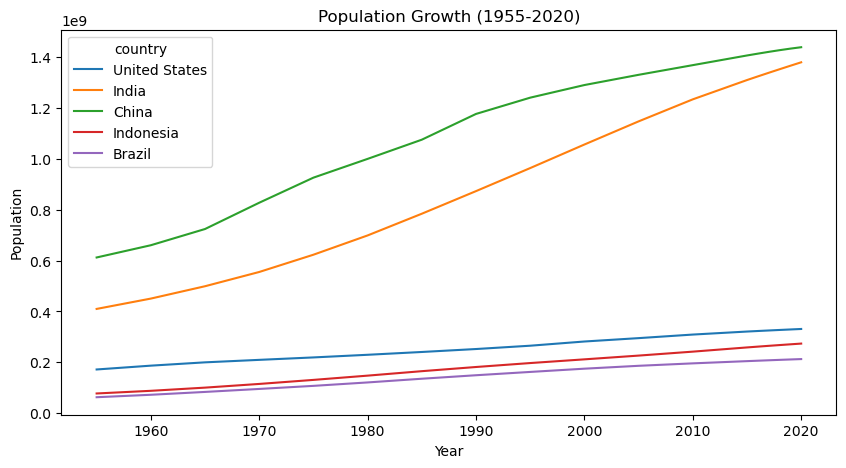

In [8]:
df_pivot.plot(
    kind="line",
    figsize=(10,5),
    title="Population Growth (1955-2020)"
)

plt.xlabel("Year")
plt.ylabel("Population")
plt.show()

<Axes: title={'center': 'Population (1955-2020)'}, xlabel='Year', ylabel='Population'>

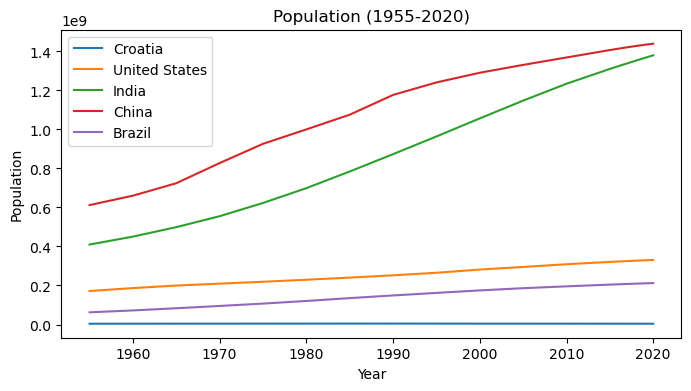

In [34]:
# other way
df_pivot.plot(kind="line", xlabel="Year", ylabel="Population", title="Population (1955-2020)", figsize=(8,4))

## Barplot - Population in 2020

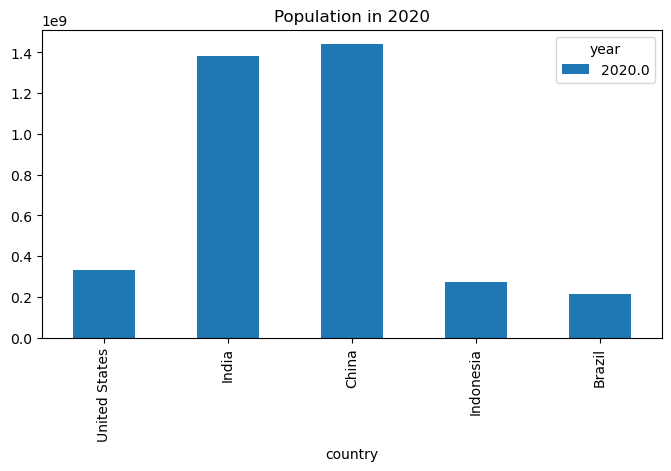

In [9]:
df_2020 = df_pivot.loc[[2020]].T

df_2020.plot(kind="bar", figsize=(8,4))
plt.title("Population in 2020")
plt.show()

In [12]:
df_pivot_2020 = df_pivot[df_pivot.index.isin([2020])]
df_pivot_2020

country,United States,India,China,Indonesia,Brazil
year,,,,,
2020.0,331002651.0,1.380004e+09,1.439324e+09,273523615.0,212559417.0


In [15]:
# transpozing dataframe from rows to columns
df_pivot_2020 = df_pivot_2020.T

<Axes: title={'center': 'Population (2020)'}, xlabel='Year', ylabel='Population'>

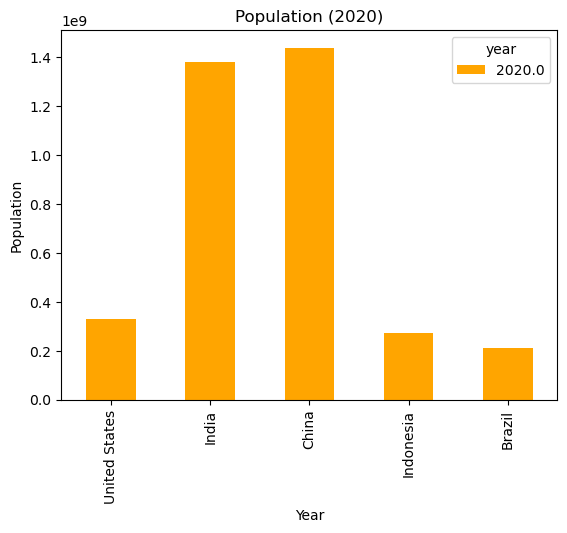

In [16]:
df_pivot_2020.plot(kind="bar", color="orange", xlabel="Year", ylabel="Population", title="Population (2020)")

## Barplot grouped by n variables

In [17]:
# selectign a few years
df_pivot_sample = df_pivot[df_pivot.index.isin([1980, 1990, 2000, 2010, 2020])]

In [18]:
df_pivot_sample

country,United States,India,China,Indonesia,Brazil
year,,,,,
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
2000.0,281710909.0,1.056576e+09,1.290551e+09,211513823.0,174790340.0
2010.0,309011475.0,1.234281e+09,1.368811e+09,241834215.0,195713635.0
2020.0,331002651.0,1.380004e+09,1.439324e+09,273523615.0,212559417.0


<Axes: title={'center': 'Population every 10 years'}, xlabel='Year', ylabel='Population'>

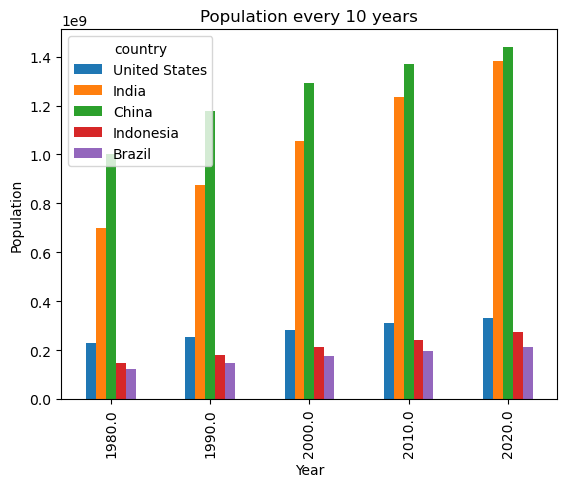

In [19]:
# grouped barplot
df_pivot_sample.plot(kind = "bar", xlabel="Year", ylabel="Population", title="Population every 10 years")

## Piechart

In [21]:
# changing column name
df_pivot_2020.rename(columns={2020:"2020"}, inplace=True)

<Axes: title={'center': 'Population in 2020(%'}, ylabel='2020'>

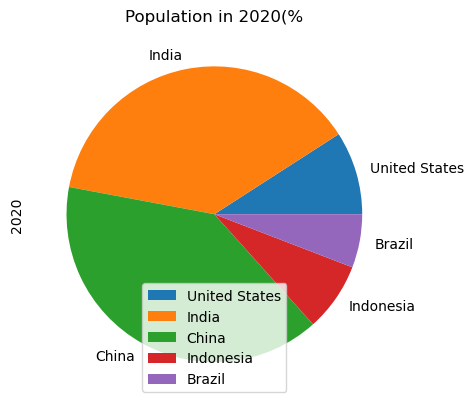

In [22]:
df_pivot_2020.plot(kind="pie", y="2020", title="Population in 2020(%")

## Boxplot

In [23]:
df_pivot

country,United States,India,China,Indonesia,Brazil
year,,,,,
1955.0,171685336.0,4.098806e+08,6.122416e+08,77273425.0,62533919.0
1960.0,186720571.0,4.505477e+08,6.604081e+08,87751068.0,72179226.0
1965.0,199733676.0,4.991233e+08,7.242190e+08,100267062.0,83373530.0
1970.0,209513341.0,5.551898e+08,8.276014e+08,114793178.0,95113265.0
1975.0,219081251.0,6.231029e+08,9.262409e+08,130680727.0,107216205.0
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1985.0,240499825.0,7.843600e+08,1.075589e+09,164982451.0,135274080.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
1995.0,265163745.0,9.639226e+08,1.240921e+09,196934260.0,162019896.0


<Axes: ylabel='Population'>

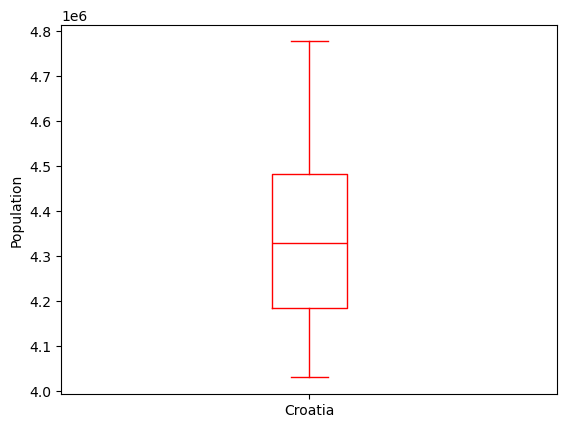

In [25]:
df_pivot = pd.read_csv("df_pivot.csv", index_col=0)
df_pivot["Croatia"].plot(kind="box", color="red", ylabel="Population")

<Axes: ylabel='Population'>

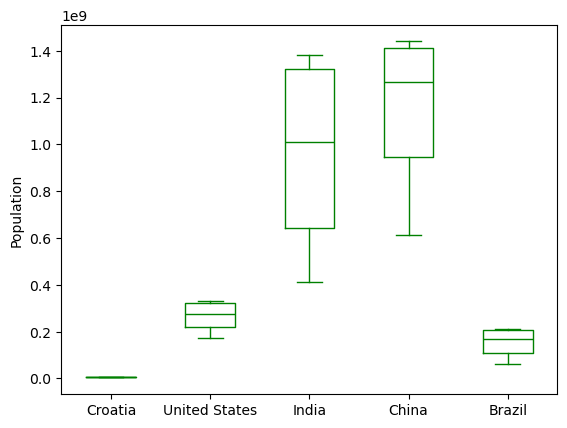

In [26]:
# multiple boxplot
df_pivot.plot(kind="box", color = "green", ylabel="Population")

## Histogram

<Axes: ylabel='Frequency'>

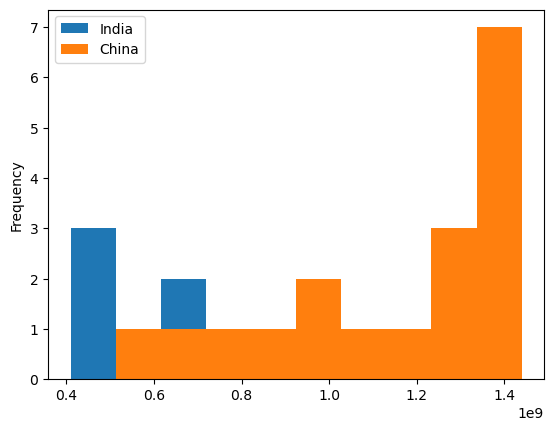

In [27]:
df_pivot[["India", "China"]].plot(kind="hist")

# ScatterPlot

In [28]:
df_population_raw = pd.read_csv("population_total.csv")

In [29]:
df_population_raw

,country,year,population
0,China,2020.0,1.439324e+09
1,China,2019.0,1.433784e+09
2,China,2018.0,1.427648e+09
3,China,2017.0,1.421022e+09
4,China,2016.0,1.414049e+09
...,...,...,...
4180,United States,1965.0,1.997337e+08
4181,United States,1960.0,1.867206e+08
4182,United States,1955.0,1.716853e+08
4183,India,1960.0,4.505477e+08


In [30]:
df_scatter_plot = df_population_raw[df_population_raw["country"].isin(["Croatia", "Serbia", "Hungary", "Slovenia"])]

<Axes: xlabel='year', ylabel='population'>

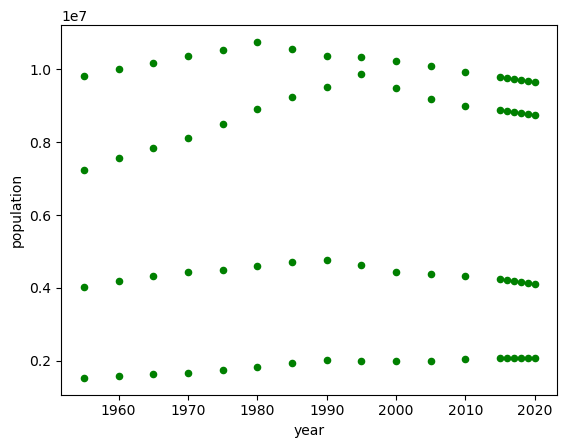

In [31]:
df_scatter_plot.plot(kind="scatter",
                    x= "year",
                    y= "population",
                    color = "green")

## Export Data

In [35]:
df_pivot.to_excel("pivot_table.xlsx")